In [6]:
pip install earthaccess


   ----------------- ---------------------- 3/7 [importlib-resources]
   ---------------------------------- ----- 6/7 [earthaccess]
   ---------------------------------------- 7/7 [earthaccess]

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install netCDF4 h5netcdf

Note: you may need to restart the kernel to use updated packages.


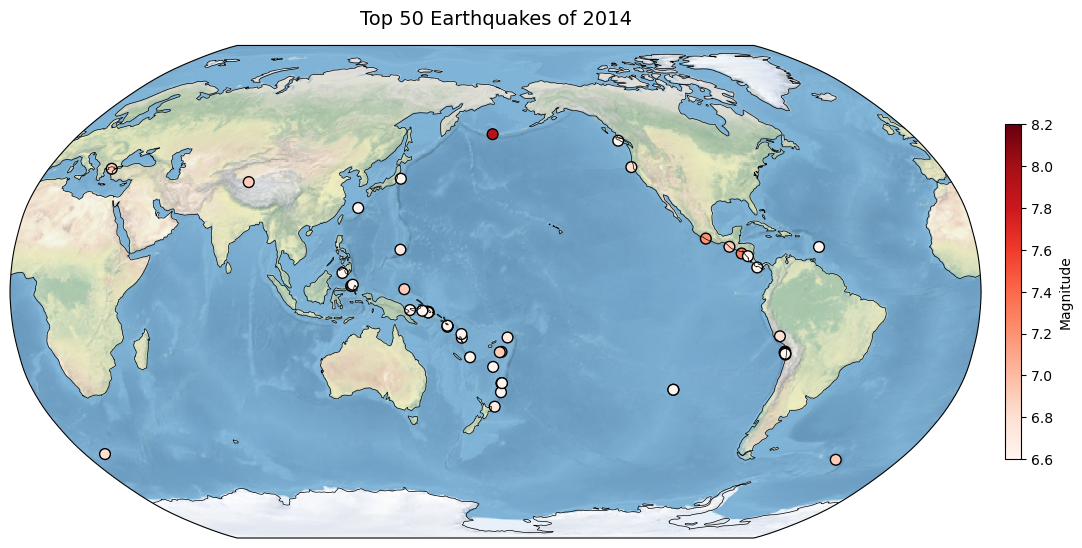

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# 1. 数据获取
try:
    df = pd.read_csv('usgs_earthquakes.csv')
    
    # 筛选 2014 年数据
    if 'time' in df.columns:
        df['year'] = pd.to_datetime(df['time']).dt.year
        df = df[df['year'] == 2014]

    # 取震级最大的前 50 个
    top50 = df.sort_values(by='mag', ascending=False).head(51)

except FileNotFoundError:
    print("未找到文件，使用模拟数据...")
    # 模拟环太平洋地震带数据 (太平洋两侧)
    data = {'latitude': np.concatenate([np.random.uniform(-60, 60, 25), np.random.uniform(0, 50, 25)]),'longitude': np.concatenate([np.random.uniform(120, 180, 25), np.random.uniform(-180, -70, 25)]),'mag': np.linspace(8.2, 6.6, 50)}
    top50 = pd.DataFrame(data)

# 2. 绘图设置
fig = plt.figure(figsize=(12, 7))

# 使用 Robinson 投影，并将中心经度设为 180 以完整展示太平洋
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))

ax.stock_img()
ax.coastlines(resolution='110m', linewidth=0.5)

# 3. 绘制散点
sc = ax.scatter(top50['longitude'], top50['latitude'], c=top50['mag'],cmap='Reds',s=60,edgecolors='black',linewidth=1,transform=ccrs.PlateCarree(),alpha=1.0,vmin=6.6, vmax=8.2)

# 4. 图例与标题
cbar = plt.colorbar(sc, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Magnitude')

plt.title('Top 50 Earthquakes of 2014', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

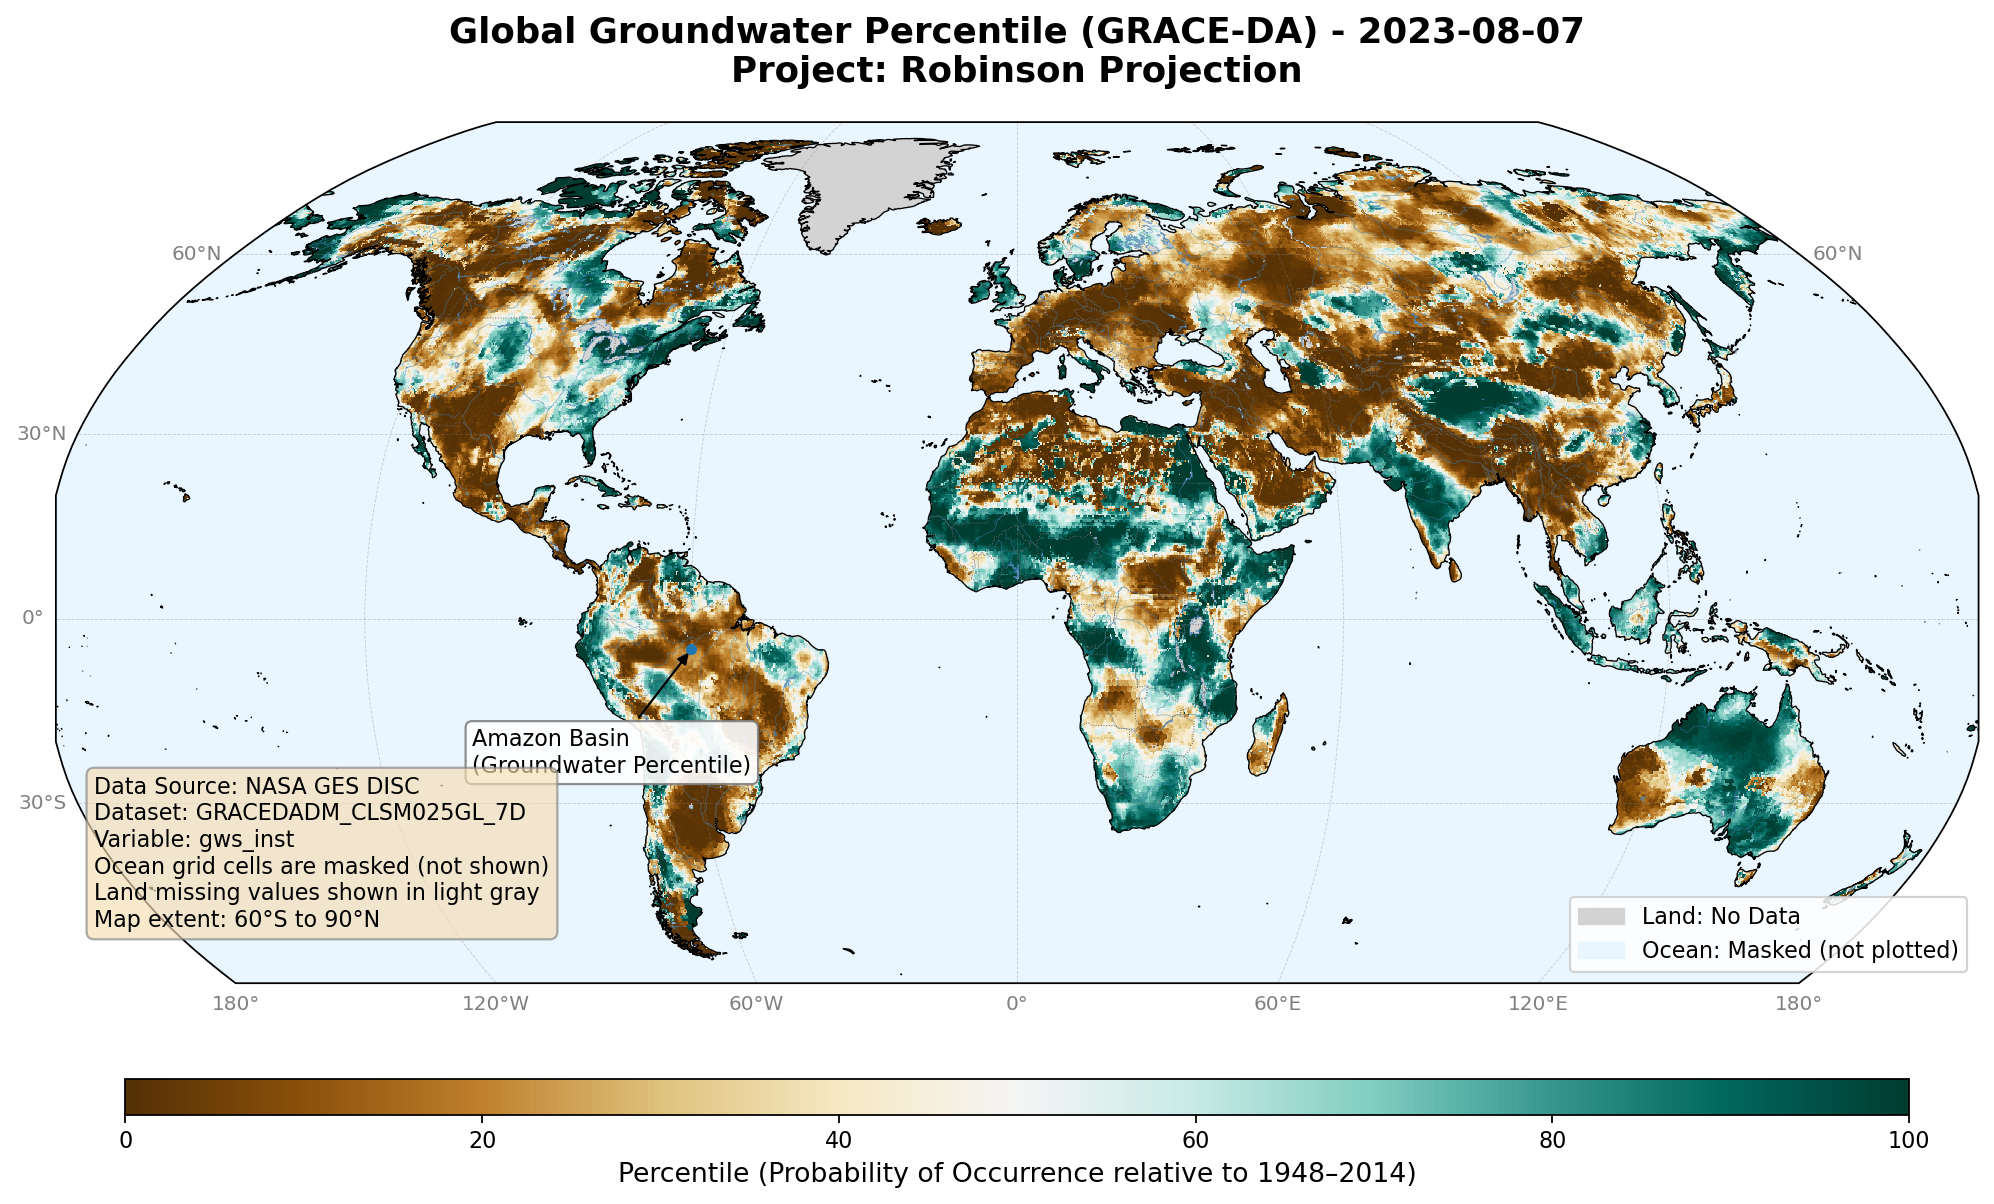

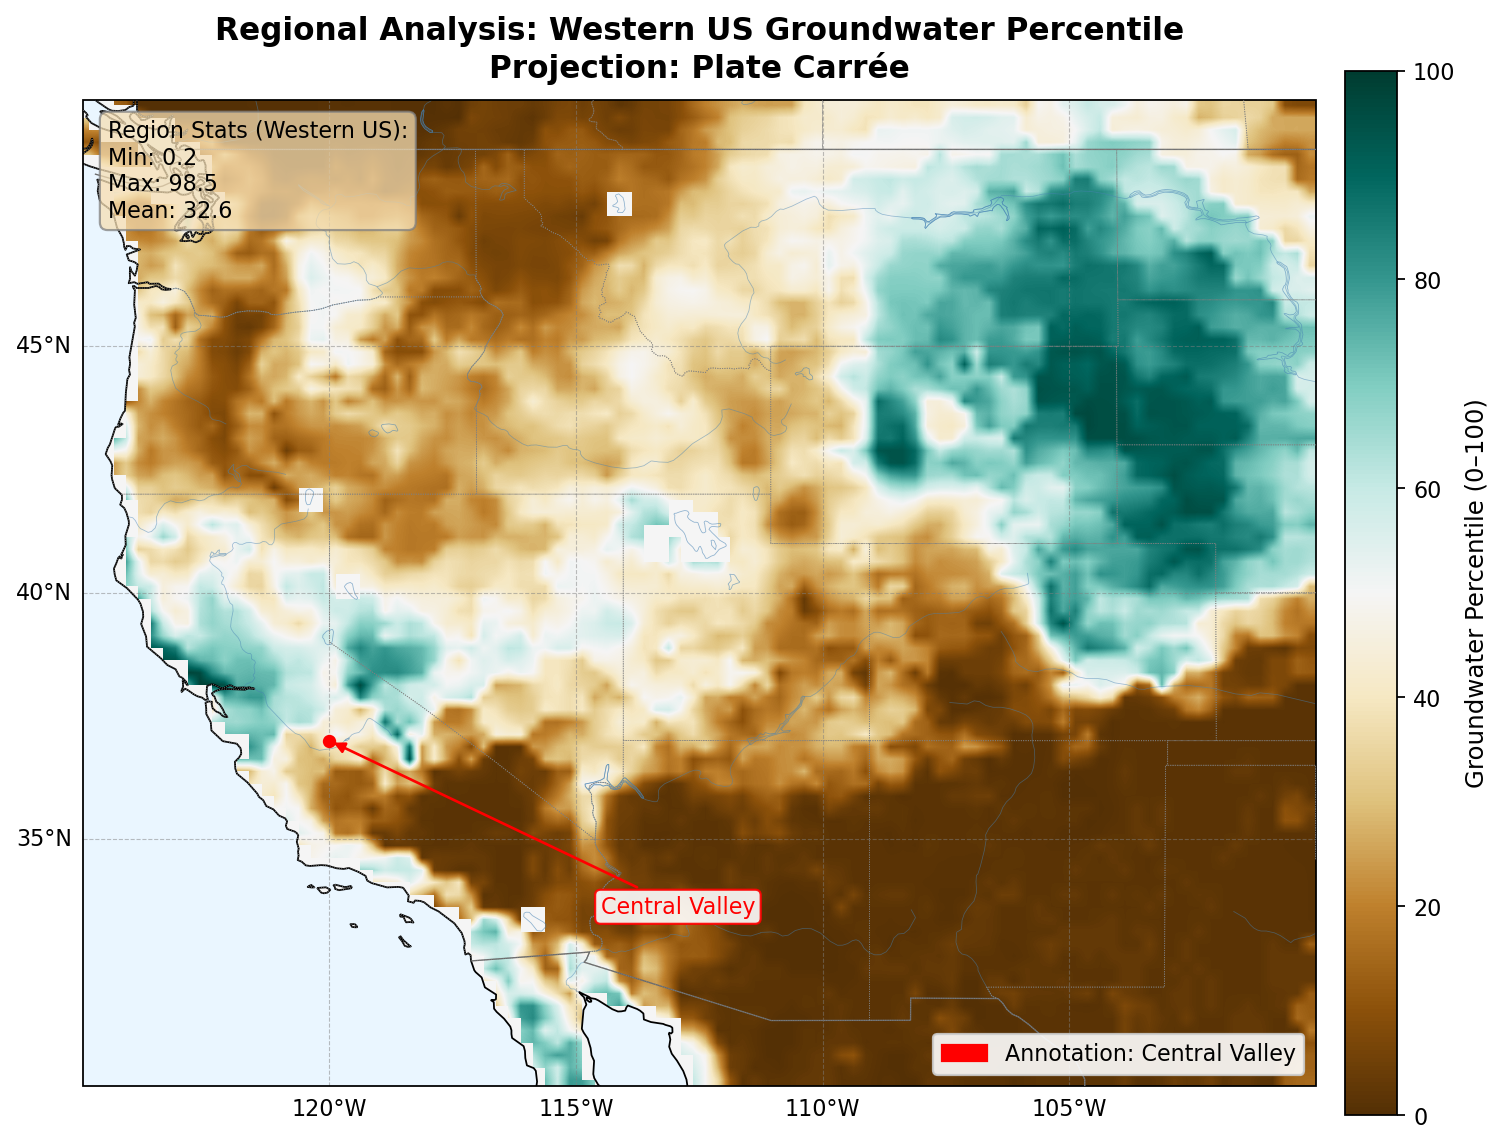

In [19]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.io.shapereader as shpreader

# --- 依赖库兼容处理 ---
try:
    from shapely import contains_xy
    _use_contains_xy = True
except ImportError:
    import shapely.vectorized as sv  # 兼容 Shapely < 2.0
    _use_contains_xy = False

# ... (前序数据加载代码略) ...

# --- 掩膜计算 ---
for geom in land_geoms:
    if _use_contains_xy:
        land_mask |= contains_xy(geom, lon2d, lat2d)
    else:
        land_mask |= sv.contains(geom, lon2d, lat2d)

# 数据预处理：转 float 以处理 NaN
data = gw_data.astype("float64").values

# 区分 "陆地上的缺测" 和 "海洋"
land_missing = land_mask & (~np.isfinite(data))

# 构造绘图数据
data_for_plot = data.copy()
# 哨兵值设为 -1，配合 cmap.set_under 显示特定颜色
data_for_plot[land_missing] = -1.0 

# 掩膜掉海洋区域
plot_arr = np.ma.array(data_for_plot, mask=~land_mask)

# 色标配置
cmap = plt.cm.BrBG.copy()
cmap.set_under("lightgray")  # 陆地缺测区域颜色

# ============================
# 全球地图 (Robinson 投影)
# ============================

fig = plt.figure(figsize=(14, 8), dpi=160)
ax = plt.axes(projection=ccrs.Robinson())

# 视图范围
ax.set_global()
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# 基础地理底图
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#eaf6ff", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f5f5f5", zorder=0)

# 边界线条
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="black", facecolor="none", zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.45, linestyle=":", edgecolor="dimgray", facecolor="none", zorder=3)

# 水系要素
ax.add_feature(cfeature.LAKES.with_scale("50m"), facecolor="none", edgecolor="steelblue", linewidth=0.35, alpha=0.7, zorder=2)
ax.add_feature(cfeature.RIVERS.with_scale("50m"), edgecolor="steelblue", linewidth=0.30, alpha=0.6, zorder=2)

# 绘制主数据
im = ax.pcolormesh(gw_data[lon_name].values,gw_data[lat_name].values,plot_arr,transform=ccrs.PlateCarree(),cmap=cmap,vmin=0, vmax=100,shading="auto",rasterized=True,zorder=1)

# 经纬网格配置
gl = ax.gridlines(linewidth=0.4, color="gray", alpha=0.35, linestyle="--", draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 91, 30))
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()
gl.xlabel_style = {"size": 9, "color": "gray"}
gl.ylabel_style = {"size": 9, "color": "gray"}

ax.set_title(f"Global Groundwater Percentile (GRACE-DA) - {date_str}\nProject: Robinson Projection",fontsize=16, fontweight="bold", pad=18)

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.085, aspect=50, shrink=0.82)
cbar.set_label("Percentile (Probability of Occurrence relative to 1948–2014)", fontsize=12)
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.ax.tick_params(labelsize=10)

# 注记：亚马逊流域
ax.plot(-60, -5, marker="o", markersize=4, transform=ccrs.PlateCarree(), zorder=5)
ax.annotate("Amazon Basin\n(Groundwater Percentile)",xy=(-60, -5),xytext=(-103, -25),xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),arrowprops=dict(arrowstyle="-|>", color="black", lw=1),fontsize=10,bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),zorder=6)

# 数据源说明
text_str = (
    "Data Source: NASA GES DISC\n"
    "Dataset: GRACEDADM_CLSM025GL_7D\n"
    f"Variable: {var_name}\n"
    "Ocean grid cells are masked (not shown)\n"
    "Land missing values shown in light gray\n"
    "Map extent: 60°S to 90°N"
)

ax.text(0.02, 0.06, text_str,transform=ax.transAxes, fontsize=10,va="bottom", ha="left",bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", edgecolor="gray", alpha=0.65),zorder=7)

# 自定义图例 (解释掩膜)
land_missing_patch = mpatches.Patch(color="lightgray", label="Land: No Data")
ocean_mask_patch = mpatches.Patch(color="#eaf6ff", label="Ocean: Masked (not plotted)")
ax.legend(handles=[land_missing_patch, ocean_mask_patch], loc="lower right", framealpha=0.85)

plt.tight_layout()
plt.show()

# ============================
# 区域地图 (美国西部)
# ============================

fig2 = plt.figure(figsize=(10, 8), dpi=160)
ax2 = plt.axes(projection=ccrs.PlateCarree())

extent = [-125, -100, 30, 50]  # [W, E, S, N]
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# 区域底图要素
ax2.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#eaf6ff", zorder=0)
ax2.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f5f5f5", zorder=0)
ax2.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8, edgecolor="black", facecolor="none", zorder=3)
ax2.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6, edgecolor="dimgray", facecolor="none", zorder=3)
ax2.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, linestyle=":", edgecolor="gray", facecolor="none", zorder=3)
ax2.add_feature(cfeature.RIVERS.with_scale("50m"), linewidth=0.35, edgecolor="steelblue", alpha=0.5, zorder=2)
ax2.add_feature(cfeature.LAKES.with_scale("50m"), facecolor="none", edgecolor="steelblue", linewidth=0.35, alpha=0.6, zorder=2)

# 数据切片
sub = gw_data.sel(**{lat_name: slice(extent[2], extent[3]), lon_name: slice(extent[0], extent[1])})

# 绘制区域数据 (bilinear 插值平滑)
img = ax2.imshow(sub.values,origin="lower",extent=extent,transform=ccrs.PlateCarree(),cmap=plt.cm.BrBG,vmin=0, vmax=100,interpolation="bilinear",zorder=1)

# 区域网格
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl2.top_labels = False
gl2.right_labels = False
gl2.xlocator = mticker.FixedLocator(np.arange(-125, -99, 5))
gl2.ylocator = mticker.FixedLocator(np.arange(30, 51, 5))
gl2.xformatter = LongitudeFormatter()
gl2.yformatter = LatitudeFormatter()
gl2.xlabel_style = {"size": 10}
gl2.ylabel_style = {"size": 10}

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

ax2.set_title(
    "Regional Analysis: Western US Groundwater Percentile\nProjection: Plate Carrée",
    fontsize=14, fontweight="bold", pad=10
)

# 竖直 Colorbar
cbar2 = plt.colorbar(img, ax=ax2, orientation="vertical", pad=0.02, shrink=0.85)
cbar2.set_label("Groundwater Percentile (0–100)", fontsize=11)
cbar2.set_ticks([0, 20, 40, 60, 80, 100])

# 重点区域标注：加州中央谷地
ax2.plot(-120, 37, marker="o", markersize=5, color="red", transform=ccrs.PlateCarree(), zorder=5)
ax2.annotate("Central Valley",xy=(-120, 37),xytext=(-114.5, 33.5),xycoords=ccrs.PlateCarree()._as_mpl_transform(ax2),arrowprops=dict(arrowstyle="-|>", color="red", lw=1.2),fontsize=10, color="red",bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.9),zorder=6)

# 区域统计信息
sub_vals = sub.values.astype("float64")
stats_text = (
    "Region Stats (Western US):\n"
    f"Min: {np.nanmin(sub_vals):.1f}\n"
    f"Max: {np.nanmax(sub_vals):.1f}\n"
    f"Mean: {np.nanmean(sub_vals):.1f}"
)

ax2.text(0.02, 0.98, stats_text,transform=ax2.transAxes, fontsize=10,va="top", ha="left",bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", edgecolor="gray", alpha=0.75),zorder=7)

# 图例
central_valley_patch = mpatches.Patch(facecolor="red", edgecolor="red", label="Annotation: Central Valley")
ax2.legend(handles=[central_valley_patch], loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()